# Module Architecture Verification Notebook

This notebook systematically verifies the two-module MLP architecture across all configurations defined in `ann_experiments.json`. It validates module functionality, communication, task routing, and provides diagnostic visualizations.

In [1]:
import os
import sys
import json
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Setup path to src module
SCRIPT_DIR = Path(__file__).parent if '__file__' in globals() else Path.cwd()
PROJECT_ROOT = SCRIPT_DIR.parent  # transfer-interference directory

# Add project root to Python path
sys.path.insert(0, str(PROJECT_ROOT))

# Project imports
from src.models.two_module_mlp import TwoModuleMLP
from src.models.neural_network import simpleLinearNet, ex_initializer_
from src.utils.basic_funcs import set_seed
from src.analysis import ann
from src.utils.visualize_architecture import visualize_two_module_mlp_nodes

# Set style
plt.style.use('default')
sns.set_palette('husl')
print('✓ Imports completed')

✓ Imports completed


## Configuration Setup

Load configurations from `ann_experiments.json` and define which configurations to verify.

In [2]:
# Load all configurations
config_path = PROJECT_ROOT / 'src' / 'models' / 'ann_experiments.json'
with open(config_path, 'r') as f:
    settings = json.load(f)

# Filter to two-module configurations (or set manually)
all_conditions = settings['conditions']
two_module_configs = [c for c in all_conditions if c.get('architecture', {}).get('type') == 'two_module']

# Define which configurations to verify
# Option 1: Verify all two-module configs (default)
CONFIGS_TO_VERIFY = [c['name'] for c in two_module_configs]

# Option 2: Manual selection (uncomment to use)
# CONFIGS_TO_VERIFY = ['two_module_rich_50_none', 'two_module_rich_50_high', 'two_module_lazy_50_none']

# Option 3: Include single-module for comparison (uncomment to use)
# CONFIGS_TO_VERIFY = ['rich_50', 'lazy_50'] + [c['name'] for c in two_module_configs]

# Verification parameters
VERIFICATION_SEED = 2024
N_TEST_SAMPLES = 20
TASK_PARAMETERS = {'nStim_perTask': 6}

# Task parameters
dim_input = TASK_PARAMETERS['nStim_perTask'] * 2  # 12
dim_output = 4

print(f'Found {len(two_module_configs)} two-module configurations')
print(f'Will verify {len(CONFIGS_TO_VERIFY)} configurations:')
for config in CONFIGS_TO_VERIFY:
    print(f'  - {config}')

Found 6 two-module configurations
Will verify 6 configurations:
  - two_module_rich_50_none
  - two_module_rich_50_low
  - two_module_rich_50_high
  - two_module_lazy_50_none
  - two_module_lazy_50_high
  - two_module_gamma_e_1_50_high


## Architecture Verification Functions

### Network Structure Verification

In [3]:
def verify_network_structure(config_name: str) -> Tuple[Optional[torch.nn.Module], Dict]:
    """
    Verify network structure: layer existence, dimensions, configuration matching.
    
    Returns:
        network: Instantiated network (or None if error)
        diagnostics: Dictionary with verification results
    """
    diagnostics = {
        'config_name': config_name,
        'structure_valid': False,
        'errors': [],
        'warnings': [],
        'layer_info': {}
    }
    
    try:
        # Find configuration
        condition = next((c for c in all_conditions if c['name'] == config_name), None)
        if not condition:
            diagnostics['errors'].append(f"Configuration '{config_name}' not found")
            return None, diagnostics
        
        # Get architecture config
        architecture_config = condition.get('architecture', None)
        is_two_module = (architecture_config is not None and 
                        architecture_config.get('type') == 'two_module')
        
        dim_hidden = condition['dim_hidden']
        gamma = condition.get('gamma', 1e-3)
        init_type = condition.get('init_type', 'custom')
        
        # Instantiate network
        if is_two_module:
            comm_bandwidth = architecture_config.get('comm_bandwidth', 'none')
            comm_scale = architecture_config.get('comm_scale', None)
            network = TwoModuleMLP(dim_input, dim_hidden, dim_output, 
                                  comm_bandwidth=comm_bandwidth, comm_scale=comm_scale)
            
            # Verify layer existence
            required_layers = ['mod_A', 'mod_B', 'readout_A', 'readout_B']
            for layer_name in required_layers:
                if not hasattr(network, layer_name):
                    diagnostics['errors'].append(f"Missing required layer: {layer_name}")
                else:
                    layer = getattr(network, layer_name)
                    diagnostics['layer_info'][layer_name] = {
                        'shape': tuple(layer.weight.shape),
                        'exists': True
                    }
            
            # Verify communication layers
            if comm_bandwidth != "none":
                if network.comm_AB is None or network.comm_BA is None:
                    diagnostics['errors'].append(f"Communication layers missing for comm_bandwidth='{comm_bandwidth}'")
                else:
                    diagnostics['layer_info']['comm_AB'] = {
                        'shape': tuple(network.comm_AB.weight.shape),
                        'exists': True
                    }
                    diagnostics['layer_info']['comm_BA'] = {
                        'shape': tuple(network.comm_BA.weight.shape),
                        'exists': True
                    }
                    diagnostics['comm_scale'] = network.comm_scale
            else:
                if network.comm_AB is not None or network.comm_BA is not None:
                    diagnostics['warnings'].append("Communication layers exist but comm_bandwidth='none'")
                else:
                    diagnostics['layer_info']['comm_AB'] = {'exists': False}
                    diagnostics['layer_info']['comm_BA'] = {'exists': False}
            
            # Verify dimensions
            expected_hidden_per_module = dim_hidden // 2
            if network.dim_hidden_per_module != expected_hidden_per_module:
                diagnostics['errors'].append(
                    f"Hidden dimension mismatch: expected {expected_hidden_per_module} per module, "
                    f"got {network.dim_hidden_per_module}"
                )
            
            # Check layer dimensions
            if network.mod_A.weight.shape != (expected_hidden_per_module, dim_input):
                diagnostics['errors'].append(
                    f"mod_A shape mismatch: expected ({expected_hidden_per_module}, {dim_input}), "
                    f"got {network.mod_A.weight.shape}"
                )
            
            if network.readout_A.weight.shape != (dim_output, expected_hidden_per_module):
                diagnostics['errors'].append(
                    f"readout_A shape mismatch: expected ({dim_output}, {expected_hidden_per_module}), "
                    f"got {network.readout_A.weight.shape}"
                )
            
        else:
            # Single-module network
            network = simpleLinearNet(dim_input, dim_hidden, dim_output)
            diagnostics['layer_info']['in_hid'] = {
                'shape': tuple(network.in_hid.weight.shape),
                'exists': True
            }
            diagnostics['layer_info']['hid_out'] = {
                'shape': tuple(network.hid_out.weight.shape),
                'exists': True
            }
        
        # Initialize weights
        ex_initializer_(network, gamma, init_type=init_type)
        
        # Verify network properties
        diagnostics['architecture_type'] = 'two_module' if is_two_module else 'single_module'
        diagnostics['dim_input'] = dim_input
        diagnostics['dim_hidden'] = dim_hidden
        diagnostics['dim_output'] = dim_output
        if is_two_module:
            diagnostics['comm_bandwidth'] = comm_bandwidth
        
        # Structure is valid if no errors
        diagnostics['structure_valid'] = len(diagnostics['errors']) == 0
        
    except Exception as e:
        diagnostics['errors'].append(f"Exception during verification: {str(e)}")
        import traceback
        diagnostics['traceback'] = traceback.format_exc()
        network = None
    
    return network, diagnostics

# Test the function
print('Testing verify_network_structure...')
test_network, test_diagnostics = verify_network_structure(CONFIGS_TO_VERIFY[0] if CONFIGS_TO_VERIFY else 'two_module_rich_50_none')
if test_network is not None:
    print(f'✓ Structure verification function works')
    print(f'  Config: {test_diagnostics["config_name"]}')
    print(f'  Valid: {test_diagnostics["structure_valid"]}')
else:
    print(f'✗ Structure verification failed: {test_diagnostics["errors"]}')

Testing verify_network_structure...
✓ Structure verification function works
  Config: two_module_rich_50_none
  Valid: True


### Task Routing Verification

In [4]:
def verify_task_routing(network, test_inputs: torch.Tensor) -> Dict:
    """
    Verify task-based input routing.
    
    Tests:
    - task_id="A": Module A active, Module B zeros
    - task_id="B": Module B active, Module A zeros
    - No task_id: Both modules active (backward compatibility)
    """
    diagnostics = {
        'routing_valid': False,
        'errors': [],
        'warnings': [],
        'test_results': {}
    }
    
    # Check if this is a two-module network
    if not isinstance(network, TwoModuleMLP):
        diagnostics['warnings'].append("Not a two-module network, skipping routing verification")
        diagnostics['routing_valid'] = True  # Not applicable
        return diagnostics
    
    try:
        # Test 1: Task A routing
        out_A, hid_A = network(test_inputs, task_id="A")
        h_A_A, h_B_A = network.get_module_hidden_states()
        
        # Module A should be active (non-zero)
        h_A_norm = h_A_A.norm().item()
        h_B_norm = h_B_A.norm().item()
        
        diagnostics['test_results']['task_A'] = {
            'h_A_norm': h_A_norm,
            'h_B_norm': h_B_norm,
            'h_A_active': h_A_norm > 1e-6
        }
        
        if h_A_norm < 1e-6:
            diagnostics['errors'].append("Task A: Module A is not active (norm too small)")
        
        # Test 2: Task B routing
        out_B, hid_B = network(test_inputs, task_id="B")
        h_A_B, h_B_B = network.get_module_hidden_states()
        
        h_A_norm_B = h_A_B.norm().item()
        h_B_norm_B = h_B_B.norm().item()
        
        diagnostics['test_results']['task_B'] = {
            'h_A_norm': h_A_norm_B,
            'h_B_norm': h_B_norm_B,
            'h_B_active': h_B_norm_B > 1e-6
        }
        
        if h_B_norm_B < 1e-6:
            diagnostics['errors'].append("Task B: Module B is not active (norm too small)")
        
        # Test 3: No task_id (backward compatibility)
        out_both, hid_both = network(test_inputs, task_id=None)
        h_A_both, h_B_both = network.get_module_hidden_states()
        
        h_A_norm_both = h_A_both.norm().item()
        h_B_norm_both = h_B_both.norm().item()
        
        diagnostics['test_results']['no_task_id'] = {
            'h_A_norm': h_A_norm_both,
            'h_B_norm': h_B_norm_both,
            'both_active': h_A_norm_both > 1e-6 and h_B_norm_both > 1e-6
        }
        
        if h_A_norm_both < 1e-6 or h_B_norm_both < 1e-6:
            diagnostics['warnings'].append("No task_id: One or both modules inactive (expected both active)")
        
        # Verify outputs are different for different task IDs
        output_diff_AB = (out_A - out_B).abs().mean().item()
        diagnostics['test_results']['output_difference'] = output_diff_AB
        
        if output_diff_AB < 1e-6:
            diagnostics['warnings'].append("Outputs for Task A and Task B are identical (unexpected)")
        
        diagnostics['routing_valid'] = len(diagnostics['errors']) == 0
        
    except Exception as e:
        diagnostics['errors'].append(f"Exception during routing verification: {str(e)}")
        import traceback
        diagnostics['traceback'] = traceback.format_exc()
    
    return diagnostics

# Test the function
if test_network is not None and isinstance(test_network, TwoModuleMLP):
    set_seed(VERIFICATION_SEED)
    test_inputs = torch.randn(N_TEST_SAMPLES, dim_input)
    routing_diagnostics = verify_task_routing(test_network, test_inputs)
    print('✓ Task routing verification function works')
    print(f'  Valid: {routing_diagnostics["routing_valid"]}')
else:
    print('Skipping routing test (not a two-module network)')

✓ Task routing verification function works
  Valid: True


### Communication Verification

In [5]:
def verify_communication(network, test_inputs: torch.Tensor) -> Dict:
    """Verify bidirectional communication flow and scale application."""
    diagnostics = {'communication_valid': False, 'errors': [], 'warnings': [], 'test_results': {}}
    
    if not isinstance(network, TwoModuleMLP):
        diagnostics['warnings'].append("Not a two-module network, skipping communication verification")
        diagnostics['communication_valid'] = True
        return diagnostics
    
    try:
        comm_bandwidth = network.comm_bandwidth
        
        if comm_bandwidth == "none":
            if network.comm_AB is not None or network.comm_BA is not None:
                diagnostics['errors'].append("Communication layers exist but comm_bandwidth='none'")
            else:
                diagnostics['communication_valid'] = True
                diagnostics['test_results']['comm_enabled'] = False
            return diagnostics
        
        diagnostics['test_results']['comm_enabled'] = True
        diagnostics['test_results']['comm_bandwidth'] = comm_bandwidth
        diagnostics['test_results']['comm_scale'] = network.comm_scale
        
        if network.comm_AB is None or network.comm_BA is None:
            diagnostics['errors'].append("Communication layers missing")
            return diagnostics
        
        # Test: Verify communication affects inactive module
        out_A, _ = network(test_inputs, task_id="A")
        h_A_A, h_B_A = network.get_module_hidden_states()
        h_B_norm = h_B_A.norm().item()
        diagnostics['test_results']['task_A_h_B_norm'] = h_B_norm
        
        if h_B_norm < 1e-8:
            diagnostics['warnings'].append(f"Task A: Module B activation very small (norm={h_B_norm:.2e})")
        
        out_B, _ = network(test_inputs, task_id="B")
        h_A_B, h_B_B = network.get_module_hidden_states()
        h_A_norm = h_A_B.norm().item()
        diagnostics['test_results']['task_B_h_A_norm'] = h_A_norm
        
        if h_A_norm < 1e-8:
            diagnostics['warnings'].append(f"Task B: Module A activation very small (norm={h_A_norm:.2e})")
        
        comm_AB_norm = network.comm_AB.weight.norm().item()
        comm_BA_norm = network.comm_BA.weight.norm().item()
        diagnostics['test_results']['comm_AB_weight_norm'] = comm_AB_norm
        diagnostics['test_results']['comm_BA_weight_norm'] = comm_BA_norm
        
        diagnostics['communication_valid'] = len(diagnostics['errors']) == 0
        
    except Exception as e:
        diagnostics['errors'].append(f"Exception: {str(e)}")
        import traceback
        diagnostics['traceback'] = traceback.format_exc()
    
    return diagnostics

# Test the function
if test_network is not None and isinstance(test_network, TwoModuleMLP):
    comm_diagnostics = verify_communication(test_network, test_inputs)
    print('✓ Communication verification function works')
    print(f'  Valid: {comm_diagnostics["communication_valid"]}')
    if comm_diagnostics['test_results'].get('comm_enabled'):
        print(f'  Comm bandwidth: {comm_diagnostics["test_results"]["comm_bandwidth"]}')
        print(f'  Comm scale: {comm_diagnostics["test_results"]["comm_scale"]}')
else:
    print('Skipping communication test (not a two-module network)')

✓ Communication verification function works
  Valid: True


### Weight Pattern Analysis

In [6]:
def analyze_weight_patterns(network) -> Dict:
    """Analyze weight patterns: statistics, distributions, comparisons."""
    diagnostics = {'weight_stats': {}, 'comparisons': {}}
    
    try:
        if isinstance(network, TwoModuleMLP):
            weights = {
                'mod_A': network.mod_A.weight.detach().cpu().numpy(),
                'mod_B': network.mod_B.weight.detach().cpu().numpy(),
                'readout_A': network.readout_A.weight.detach().cpu().numpy(),
                'readout_B': network.readout_B.weight.detach().cpu().numpy(),
            }
            
            if network.comm_AB is not None:
                weights['comm_AB'] = network.comm_AB.weight.detach().cpu().numpy()
                weights['comm_BA'] = network.comm_BA.weight.detach().cpu().numpy()
            
            for layer_name, weight_matrix in weights.items():
                diagnostics['weight_stats'][layer_name] = {
                    'mean': float(np.mean(weight_matrix)),
                    'std': float(np.std(weight_matrix)),
                    'norm': float(np.linalg.norm(weight_matrix)),
                    'min': float(np.min(weight_matrix)),
                    'max': float(np.max(weight_matrix)),
                    'shape': weight_matrix.shape
                }
            
            mod_A_stats = diagnostics['weight_stats']['mod_A']
            mod_B_stats = diagnostics['weight_stats']['mod_B']
            
            diagnostics['comparisons']['mod_A_vs_mod_B'] = {
                'mean_diff': abs(mod_A_stats['mean'] - mod_B_stats['mean']),
                'std_diff': abs(mod_A_stats['std'] - mod_B_stats['std']),
                'norm_ratio': mod_A_stats['norm'] / (mod_B_stats['norm'] + 1e-10)
            }
        else:
            weights = {
                'in_hid': network.in_hid.weight.detach().cpu().numpy(),
                'hid_out': network.hid_out.weight.detach().cpu().numpy(),
            }
            
            for layer_name, weight_matrix in weights.items():
                diagnostics['weight_stats'][layer_name] = {
                    'mean': float(np.mean(weight_matrix)),
                    'std': float(np.std(weight_matrix)),
                    'norm': float(np.linalg.norm(weight_matrix)),
                    'min': float(np.min(weight_matrix)),
                    'max': float(np.max(weight_matrix)),
                    'shape': weight_matrix.shape
                }
        
    except Exception as e:
        diagnostics['error'] = str(e)
        import traceback
        diagnostics['traceback'] = traceback.format_exc()
    
    return diagnostics

# Test the function
if test_network is not None:
    weight_diagnostics = analyze_weight_patterns(test_network)
    print('✓ Weight pattern analysis function works')
    if 'weight_stats' in weight_diagnostics:
        print(f'  Analyzed {len(weight_diagnostics["weight_stats"])} weight matrices')

✓ Weight pattern analysis function works
  Analyzed 4 weight matrices


## Connectivity Visualization

### Weight Matrix Heatmaps

Creating connectivity matrix visualization...


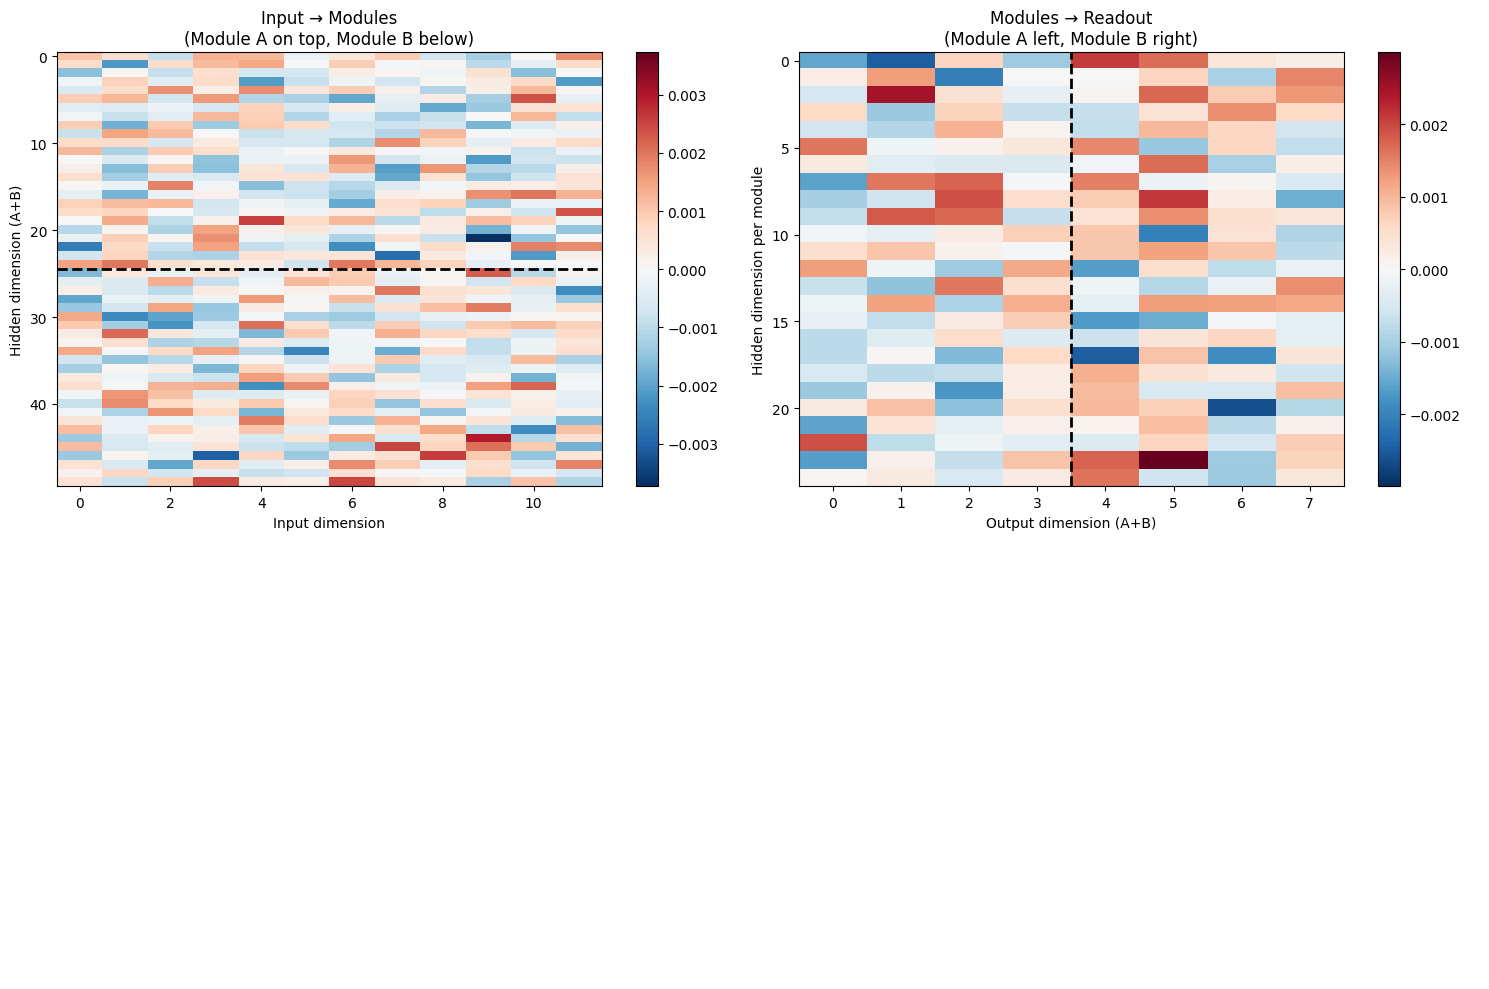

✓ Connectivity matrix visualization works


In [7]:
def visualize_connectivity_matrix(network, layer_pair: str = 'all', figsize=(15, 10), save_path=None):
    """Create heatmap visualizations of weight matrices."""
    if not isinstance(network, TwoModuleMLP):
        print('Visualization only supports two-module networks')
        return None
    
    if layer_pair == 'all':
        n_plots = 4 if network.comm_bandwidth != 'none' else 2
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        axes = axes.flatten()
        plot_idx = 0
        
        # Input to Modules
        ax = axes[plot_idx]
        mod_A_weights = network.mod_A.weight.detach().cpu().numpy()
        mod_B_weights = network.mod_B.weight.detach().cpu().numpy()
        combined = np.vstack([mod_A_weights, mod_B_weights])
        im = ax.imshow(combined, aspect='auto', cmap='RdBu_r', vmin=-np.abs(combined).max(), vmax=np.abs(combined).max())
        ax.set_title('Input → Modules\n(Module A on top, Module B below)')
        ax.set_xlabel('Input dimension')
        ax.set_ylabel('Hidden dimension (A+B)')
        ax.axhline(y=mod_A_weights.shape[0]-0.5, color='black', linewidth=2, linestyle='--')
        plt.colorbar(im, ax=ax)
        plot_idx += 1
        
        # Modules to Readout
        ax = axes[plot_idx]
        readout_A_weights = network.readout_A.weight.detach().cpu().numpy()
        readout_B_weights = network.readout_B.weight.detach().cpu().numpy()
        combined_readout = np.hstack([readout_A_weights.T, readout_B_weights.T])
        im = ax.imshow(combined_readout, aspect='auto', cmap='RdBu_r', vmin=-np.abs(combined_readout).max(), vmax=np.abs(combined_readout).max())
        ax.set_title('Modules → Readout\n(Module A left, Module B right)')
        ax.set_xlabel('Output dimension (A+B)')
        ax.set_ylabel('Hidden dimension per module')
        ax.axvline(x=readout_A_weights.shape[0]-0.5, color='black', linewidth=2, linestyle='--')
        plt.colorbar(im, ax=ax)
        plot_idx += 1
        
        # Communication matrices (if enabled)
        if network.comm_bandwidth != 'none' and plot_idx < len(axes):
            ax = axes[plot_idx]
            comm_AB_weights = network.comm_AB.weight.detach().cpu().numpy()
            im = ax.imshow(comm_AB_weights, aspect='auto', cmap='RdBu_r', vmin=-np.abs(comm_AB_weights).max(), vmax=np.abs(comm_AB_weights).max())
            ax.set_title(f'Communication A → B\n(scale={network.comm_scale:.3f})')
            ax.set_xlabel('Module B hidden')
            ax.set_ylabel('Module A hidden')
            plt.colorbar(im, ax=ax)
            plot_idx += 1
            
            if plot_idx < len(axes):
                ax = axes[plot_idx]
                comm_BA_weights = network.comm_BA.weight.detach().cpu().numpy()
                im = ax.imshow(comm_BA_weights, aspect='auto', cmap='RdBu_r', vmin=-np.abs(comm_BA_weights).max(), vmax=np.abs(comm_BA_weights).max())
                ax.set_title(f'Communication B → A\n(scale={network.comm_scale:.3f})')
                ax.set_xlabel('Module A hidden')
                ax.set_ylabel('Module B hidden')
                plt.colorbar(im, ax=ax)
        
        for idx in range(plot_idx, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved connectivity matrix to {save_path}')
    
    return fig

# Test visualization
if test_network is not None and isinstance(test_network, TwoModuleMLP):
    print('Creating connectivity matrix visualization...')
    fig = visualize_connectivity_matrix(test_network, layer_pair='all')
    plt.show()
    print('✓ Connectivity matrix visualization works')

### Architecture Connectivity Diagram

Creating architecture connectivity diagram...


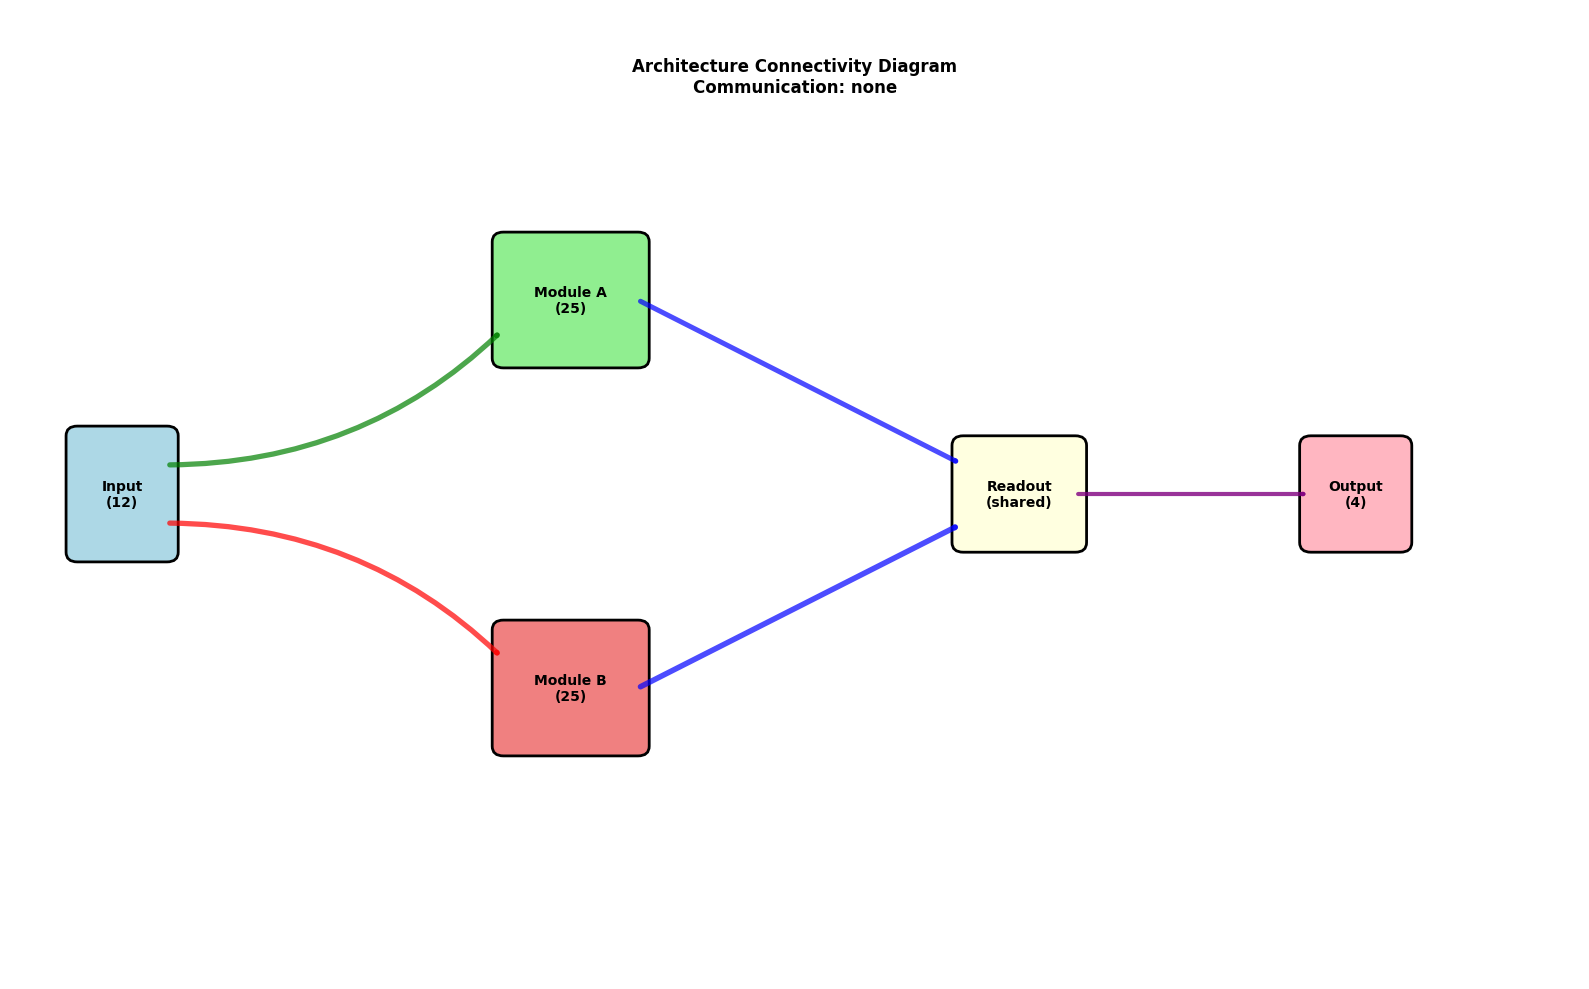

✓ Architecture connectivity diagram works


In [8]:
def visualize_architecture_connectivity(network, save_path=None, figsize=(16, 10)):
    """Create network diagram showing connectivity patterns with connection strengths."""
    if not isinstance(network, TwoModuleMLP):
        print('Visualization only supports two-module networks')
        return None
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Get weight matrices and compute connection strengths
    mod_A_weights = network.mod_A.weight.detach().cpu().numpy()
    mod_B_weights = network.mod_B.weight.detach().cpu().numpy()
    readout_A_weights = network.readout_A.weight.detach().cpu().numpy()
    readout_B_weights = network.readout_B.weight.detach().cpu().numpy()
    
    input_to_A_strength = np.abs(mod_A_weights).mean()
    input_to_B_strength = np.abs(mod_B_weights).mean()
    A_to_readout_strength = np.abs(readout_A_weights).mean()
    B_to_readout_strength = np.abs(readout_B_weights).mean()
    max_strength = max(input_to_A_strength, input_to_B_strength, A_to_readout_strength, B_to_readout_strength)
    
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
    
    # Define positions
    input_pos = (1, 5)
    mod_a_pos = (5, 7)
    mod_b_pos = (5, 3)
    readout_pos = (9, 5)
    output_pos = (12, 5)
    
    # Draw layers
    input_box = FancyBboxPatch((input_pos[0]-0.4, input_pos[1]-0.6), 0.8, 1.2,
                              boxstyle='round,pad=0.1', facecolor='lightblue', edgecolor='black', linewidth=2)
    ax.add_patch(input_box)
    ax.text(input_pos[0], input_pos[1], f'Input\n({network.input_dim})', ha='center', va='center', fontsize=10, weight='bold')
    
    mod_a_box = FancyBboxPatch((mod_a_pos[0]-0.6, mod_a_pos[1]-0.6), 1.2, 1.2,
                              boxstyle='round,pad=0.1', facecolor='lightgreen', edgecolor='black', linewidth=2)
    ax.add_patch(mod_a_box)
    ax.text(mod_a_pos[0], mod_a_pos[1], f'Module A\n({network.dim_hidden_per_module})', ha='center', va='center', fontsize=10, weight='bold')
    
    mod_b_box = FancyBboxPatch((mod_b_pos[0]-0.6, mod_b_pos[1]-0.6), 1.2, 1.2,
                              boxstyle='round,pad=0.1', facecolor='lightcoral', edgecolor='black', linewidth=2)
    ax.add_patch(mod_b_box)
    ax.text(mod_b_pos[0], mod_b_pos[1], f'Module B\n({network.dim_hidden_per_module})', ha='center', va='center', fontsize=10, weight='bold')
    
    readout_box = FancyBboxPatch((readout_pos[0]-0.5, readout_pos[1]-0.5), 1.0, 1.0,
                                boxstyle='round,pad=0.1', facecolor='lightyellow', edgecolor='black', linewidth=2)
    ax.add_patch(readout_box)
    ax.text(readout_pos[0], readout_pos[1], 'Readout\n(shared)', ha='center', va='center', fontsize=10, weight='bold')
    
    output_box = FancyBboxPatch((output_pos[0]-0.4, output_pos[1]-0.5), 0.8, 1.0,
                               boxstyle='round,pad=0.1', facecolor='lightpink', edgecolor='black', linewidth=2)
    ax.add_patch(output_box)
    ax.text(output_pos[0], output_pos[1], f'Output\n({network.output_dim})', ha='center', va='center', fontsize=10, weight='bold')
    
    def get_linewidth(strength, max_strength, min_width=1, max_width=4):
        return min_width + (strength / max_strength) * (max_width - min_width)
    
    # Input → Module A
    lw_A = get_linewidth(input_to_A_strength, max_strength)
    arrow_A = FancyArrowPatch((input_pos[0]+0.4, input_pos[1]+0.3), (mod_a_pos[0]-0.6, mod_a_pos[1]-0.3),
                             arrowstyle='->', lw=lw_A, color='green', alpha=0.7, connectionstyle='arc3,rad=0.2')
    ax.add_patch(arrow_A)
    
    # Input → Module B
    lw_B = get_linewidth(input_to_B_strength, max_strength)
    arrow_B = FancyArrowPatch((input_pos[0]+0.4, input_pos[1]-0.3), (mod_b_pos[0]-0.6, mod_b_pos[1]+0.3),
                             arrowstyle='->', lw=lw_B, color='red', alpha=0.7, connectionstyle='arc3,rad=-0.2')
    ax.add_patch(arrow_B)
    
    # Communication (if enabled)
    if network.comm_bandwidth != 'none':
        comm_AB_weights = network.comm_AB.weight.detach().cpu().numpy()
        comm_strength = np.abs(comm_AB_weights).mean()
        lw_comm = get_linewidth(comm_strength, max_strength, min_width=0.5, max_width=2)
        arrow_comm_AB = FancyArrowPatch((mod_a_pos[0]+0.6, mod_a_pos[1]-0.4), (mod_b_pos[0]+0.6, mod_b_pos[1]+0.4),
                                       arrowstyle='->', lw=lw_comm, color='orange', alpha=0.6, connectionstyle='arc3,rad=0.1')
        ax.add_patch(arrow_comm_AB)
        arrow_comm_BA = FancyArrowPatch((mod_b_pos[0]+0.6, mod_b_pos[1]+0.4), (mod_a_pos[0]+0.6, mod_a_pos[1]-0.4),
                                       arrowstyle='->', lw=lw_comm, color='orange', alpha=0.6, connectionstyle='arc3,rad=-0.1')
        ax.add_patch(arrow_comm_BA)
        ax.text(mod_a_pos[0]+1.5, 5, f'Comm\n(scale={network.comm_scale:.3f})', ha='center', fontsize=9, weight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    # Module A → Readout
    lw_readout_A = get_linewidth(A_to_readout_strength, max_strength)
    arrow_readout_A = FancyArrowPatch((mod_a_pos[0]+0.6, mod_a_pos[1]), (readout_pos[0]-0.5, readout_pos[1]+0.3),
                                     arrowstyle='->', lw=lw_readout_A, color='blue', alpha=0.7)
    ax.add_patch(arrow_readout_A)
    
    # Module B → Readout
    lw_readout_B = get_linewidth(B_to_readout_strength, max_strength)
    arrow_readout_B = FancyArrowPatch((mod_b_pos[0]+0.6, mod_b_pos[1]), (readout_pos[0]-0.5, readout_pos[1]-0.3),
                                     arrowstyle='->', lw=lw_readout_B, color='blue', alpha=0.7)
    ax.add_patch(arrow_readout_B)
    
    # Readout → Output
    arrow_output = FancyArrowPatch((readout_pos[0]+0.5, readout_pos[1]), (output_pos[0]-0.4, output_pos[1]),
                                  arrowstyle='->', lw=3, color='purple', alpha=0.8)
    ax.add_patch(arrow_output)
    
    title = f'Architecture Connectivity Diagram\nCommunication: {network.comm_bandwidth}'
    if network.comm_bandwidth != 'none':
        title += f' (scale={network.comm_scale:.3f})'
    ax.text(7, 9.5, title, ha='center', va='top', fontsize=12, weight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved connectivity diagram to {save_path}')
    
    return fig

# Test visualization
if test_network is not None and isinstance(test_network, TwoModuleMLP):
    print('Creating architecture connectivity diagram...')
    fig = visualize_architecture_connectivity(test_network)
    plt.show()
    print('✓ Architecture connectivity diagram works')

## Activation Analysis

### Module Activation Patterns

In [9]:
def analyze_module_activations(network, test_inputs: torch.Tensor, task_ids: List[str]) -> Dict:
    """Analyze module activation patterns and how communication affects them."""
    diagnostics = {'activation_stats': {}, 'comparisons': {}}
    
    if not isinstance(network, TwoModuleMLP):
        diagnostics['warning'] = 'Not a two-module network'
        return diagnostics
    
    try:
        activations = {}
        
        for task_id in task_ids:
            out, _ = network(test_inputs, task_id=task_id)
            h_A, h_B = network.get_module_hidden_states()
            
            activations[task_id] = {
                'h_A': h_A.detach().cpu().numpy(),
                'h_B': h_B.detach().cpu().numpy(),
                'output': out.detach().cpu().numpy()
            }
            
            diagnostics['activation_stats'][task_id] = {
                'h_A_mean': float(np.mean(h_A.numpy())),
                'h_A_std': float(np.std(h_A.numpy())),
                'h_A_norm': float(h_A.norm().item()),
                'h_B_mean': float(np.mean(h_B.numpy())),
                'h_B_std': float(np.std(h_B.numpy())),
                'h_B_norm': float(h_B.norm().item()),
                'output_norm': float(out.norm().item())
            }
        
        if 'A' in task_ids and 'B' in task_ids:
            h_A_A = activations['A']['h_A']
            h_B_A = activations['A']['h_B']
            h_A_B = activations['B']['h_A']
            h_B_B = activations['B']['h_B']
            
            diagnostics['comparisons']['task_A_vs_B'] = {
                'h_A_ratio': float(np.abs(h_A_A).mean() / (np.abs(h_A_B).mean() + 1e-10)),
                'h_B_ratio': float(np.abs(h_B_B).mean() / (np.abs(h_B_A).mean() + 1e-10))
            }
        
        diagnostics['activations'] = activations
        
    except Exception as e:
        diagnostics['error'] = str(e)
        import traceback
        diagnostics['traceback'] = traceback.format_exc()
    
    return diagnostics

def visualize_activation_patterns(activation_diagnostics: Dict, figsize=(15, 5)):
    """Visualize activation distributions and patterns."""
    if 'activations' not in activation_diagnostics:
        print('No activation data to visualize')
        return None
    
    activations = activation_diagnostics['activations']
    fig, axes = plt.subplots(1, len(activations), figsize=figsize)
    if len(activations) == 1:
        axes = [axes]
    
    for idx, (task_id, act_data) in enumerate(activations.items()):
        ax = axes[idx]
        
        h_A = act_data['h_A'].flatten()
        h_B = act_data['h_B'].flatten()
        
        ax.hist(h_A, bins=30, alpha=0.6, label='Module A', color='green', density=True)
        ax.hist(h_B, bins=30, alpha=0.6, label='Module B', color='red', density=True)
        ax.set_xlabel('Activation value')
        ax.set_ylabel('Density')
        ax.set_title(f'Task {task_id} Activations')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Test activation analysis
if test_network is not None and isinstance(test_network, TwoModuleMLP):
    set_seed(VERIFICATION_SEED)
    test_inputs_act = torch.randn(N_TEST_SAMPLES, dim_input)
    activation_diagnostics = analyze_module_activations(test_network, test_inputs_act, ['A', 'B'])
    print('✓ Activation analysis function works')
    
    if 'activations' in activation_diagnostics:
        print('Creating activation pattern visualization...')
        fig = visualize_activation_patterns(activation_diagnostics)
        plt.show()
        print('✓ Activation visualization works')

✓ Activation analysis function works


## Main Verification Loop

Run verification for all configurations and collect diagnostics.

In [10]:
# Set random seed for reproducibility
set_seed(VERIFICATION_SEED)

# Generate test inputs
test_inputs = torch.randn(N_TEST_SAMPLES, dim_input)

# Store all verification results
all_results = []

print(f'Starting verification for {len(CONFIGS_TO_VERIFY)} configurations...')
print('=' * 80)

for config_name in CONFIGS_TO_VERIFY:
    print(f'\n{"="*80}')
    print(f'Verifying: {config_name}')
    print(f'{"="*80}')
    
    result = {
        'config_name': config_name,
        'success': False,
        'diagnostics': {}
    }
    
    try:
        # 1. Structure verification
        print('  [1/5] Verifying network structure...')
        network, structure_diag = verify_network_structure(config_name)
        result['diagnostics']['structure'] = structure_diag
        
        if network is None:
            print(f'    ✗ Failed: {structure_diag["errors"]}')
            all_results.append(result)
            continue
        
        print(f'    ✓ Structure valid: {structure_diag["structure_valid"]}')
        if structure_diag['warnings']:
            for warning in structure_diag['warnings']:
                print(f'    ⚠ Warning: {warning}')
        
        # 2. Task routing verification (only for two-module)
        if isinstance(network, TwoModuleMLP):
            print('  [2/5] Verifying task routing...')
            routing_diag = verify_task_routing(network, test_inputs)
            result['diagnostics']['routing'] = routing_diag
            print(f'    ✓ Routing valid: {routing_diag["routing_valid"]}')
            if routing_diag['warnings']:
                for warning in routing_diag['warnings']:
                    print(f'    ⚠ Warning: {warning}')
        else:
            result['diagnostics']['routing'] = {'routing_valid': None, 'note': 'Not applicable for single-module'}
        
        # 3. Communication verification (only for two-module)
        if isinstance(network, TwoModuleMLP):
            print('  [3/5] Verifying communication...')
            comm_diag = verify_communication(network, test_inputs)
            result['diagnostics']['communication'] = comm_diag
            print(f'    ✓ Communication valid: {comm_diag["communication_valid"]}')
            if comm_diag.get('test_results', {}).get('comm_enabled'):
                print(f'    Comm bandwidth: {comm_diag["test_results"]["comm_bandwidth"]}')
                print(f'    Comm scale: {comm_diag["test_results"]["comm_scale"]}')
            if comm_diag['warnings']:
                for warning in comm_diag['warnings']:
                    print(f'    ⚠ Warning: {warning}')
        else:
            result['diagnostics']['communication'] = {'communication_valid': None, 'note': 'Not applicable for single-module'}
        
        # 4. Weight pattern analysis
        print('  [4/5] Analyzing weight patterns...')
        weight_diag = analyze_weight_patterns(network)
        result['diagnostics']['weights'] = weight_diag
        print(f'    ✓ Weight analysis completed')
        if 'weight_stats' in weight_diag:
            print(f'    Analyzed {len(weight_diag["weight_stats"])} weight matrices')
        
        # 5. Activation analysis (only for two-module)
        if isinstance(network, TwoModuleMLP):
            print('  [5/5] Analyzing activations...')
            activation_diag = analyze_module_activations(network, test_inputs, ['A', 'B'])
            result['diagnostics']['activations'] = activation_diag
            print(f'    ✓ Activation analysis completed')
        else:
            result['diagnostics']['activations'] = {'note': 'Not applicable for single-module'}
        
        result['success'] = True
        result['network'] = network  # Store network for later use
        
    except Exception as e:
        print(f'    ✗ Exception: {str(e)}')
        result['error'] = str(e)
        import traceback
        result['traceback'] = traceback.format_exc()
    
    all_results.append(result)

print(f'\n{"="*80}')
print(f'Verification completed for {len(CONFIGS_TO_VERIFY)} configurations')
print(f'{"="*80}')

Starting verification for 6 configurations...

Verifying: two_module_rich_50_none
  [1/5] Verifying network structure...
    ✓ Structure valid: True
  [2/5] Verifying task routing...
    ✓ Routing valid: True
  [3/5] Verifying communication...
    ✓ Communication valid: True
  [4/5] Analyzing weight patterns...
    ✓ Weight analysis completed
    Analyzed 4 weight matrices
  [5/5] Analyzing activations...
    ✓ Activation analysis completed

Verifying: two_module_rich_50_low
  [1/5] Verifying network structure...
    ✓ Structure valid: True
  [2/5] Verifying task routing...
    ✓ Routing valid: True
  [3/5] Verifying communication...
    ✓ Communication valid: True
    Comm bandwidth: low
    Comm scale: 0.05
  [4/5] Analyzing weight patterns...
    ✓ Weight analysis completed
    Analyzed 6 weight matrices
  [5/5] Analyzing activations...
    ✓ Activation analysis completed

Verifying: two_module_rich_50_high
  [1/5] Verifying network structure...
    ✓ Structure valid: True
  [2/5] V

### Diagnostic Summary Table

In [11]:
# Create summary DataFrame
summary_data = []

for result in all_results:
    config_name = result['config_name']
    diagnostics = result.get('diagnostics', {})
    
    structure_diag = diagnostics.get('structure', {})
    routing_diag = diagnostics.get('routing', {})
    comm_diag = diagnostics.get('communication', {})
    weight_diag = diagnostics.get('weights', {})
    
    row = {
        'config_name': config_name,
        'success': result.get('success', False),
        'architecture_type': structure_diag.get('architecture_type', 'unknown'),
        'comm_bandwidth': structure_diag.get('comm_bandwidth', 'N/A'),
        'structure_valid': structure_diag.get('structure_valid', False),
        'routing_valid': routing_diag.get('routing_valid'),
        'communication_valid': comm_diag.get('communication_valid'),
    }
    
    # Add weight statistics summary
    weight_stats = weight_diag.get('weight_stats', {})
    if weight_stats:
        first_layer = list(weight_stats.keys())[0]
        row['weight_mean_example'] = weight_stats[first_layer].get('mean', 0)
        row['weight_std_example'] = weight_stats[first_layer].get('std', 0)
    else:
        row['weight_mean_example'] = None
        row['weight_std_example'] = None
    
    # Add error count
    errors = []
    if structure_diag.get('errors'):
        errors.extend(structure_diag['errors'])
    if routing_diag.get('errors'):
        errors.extend(routing_diag['errors'])
    if comm_diag.get('errors'):
        errors.extend(comm_diag['errors'])
    row['error_count'] = len(errors)
    row['errors'] = '; '.join(errors[:3]) if errors else ''
    
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)

# Display formatted table
print('\n' + '='*100)
print('VERIFICATION SUMMARY')
print('='*100)
print(summary_df.to_string(index=False))

# Create a more readable display
print('\n' + '='*100)
print('QUICK STATUS')
print('='*100)
for _, row in summary_df.iterrows():
    status = '✓' if row['success'] else '✗'
    print(f"{status} {row['config_name']:30s} | "
          f"Structure: {'✓' if row['structure_valid'] else '✗':3s} | "
          f"Routing: {str(row['routing_valid'])[:3] if row['routing_valid'] is not None else 'N/A':3s} | "
          f"Comm: {str(row['communication_valid'])[:3] if row['communication_valid'] is not None else 'N/A':3s} | "
          f"Errors: {row['error_count']}")

# Save summary
summary_path = PROJECT_ROOT / 'figures' / 'verification_summary.csv'
summary_path.parent.mkdir(exist_ok=True)
summary_df.to_csv(summary_path, index=False)
print(f'\nSummary saved to: {summary_path}')


VERIFICATION SUMMARY
                 config_name  success architecture_type comm_bandwidth  structure_valid  routing_valid  communication_valid  weight_mean_example  weight_std_example  error_count errors
     two_module_rich_50_none     True        two_module           none             True           True                 True            -0.000014            0.000971            0       
      two_module_rich_50_low     True        two_module            low             True           True                 True            -0.000035            0.000981            0       
     two_module_rich_50_high     True        two_module           high             True           True                 True            -0.000018            0.000947            0       
     two_module_lazy_50_none     True        two_module           none             True           True                 True            -0.002864            2.022604            0       
     two_module_lazy_50_high     True        two_modu

## Comparative Visualizations

### Compare Configurations

Comparing configurations...


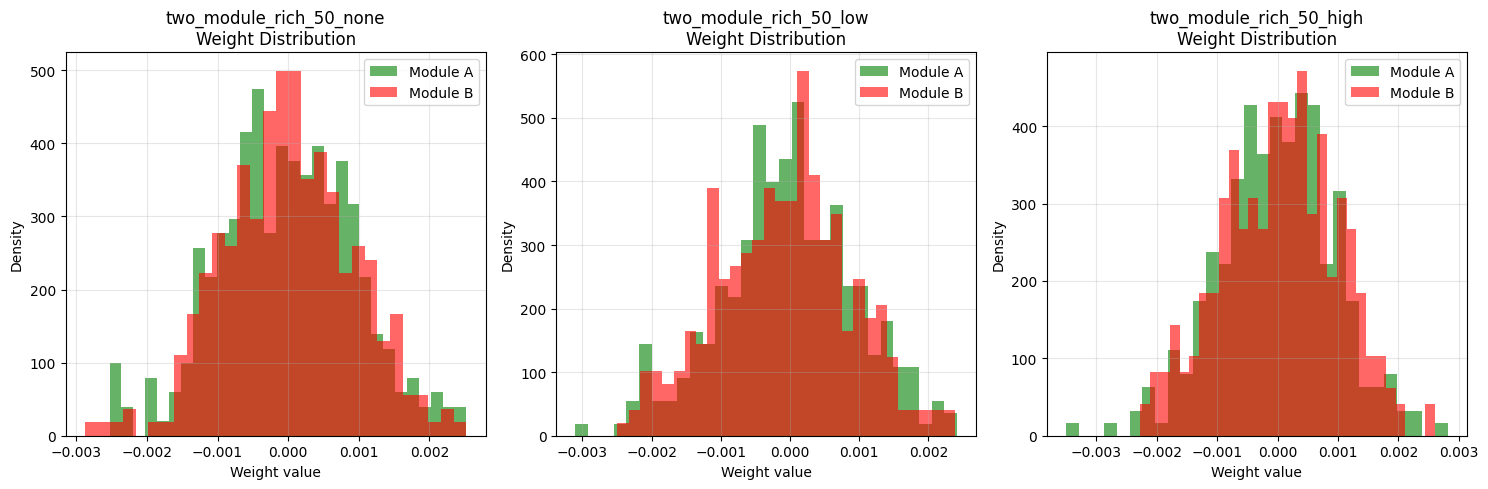

✓ Configuration comparison works


In [12]:
def compare_configurations(config_names: List[str], comparison_type: str = 'weights', figsize=(15, 5)):
    """Compare configurations side-by-side."""
    networks = {}
    for result in all_results:
        if result['config_name'] in config_names and result.get('success'):
            networks[result['config_name']] = result.get('network')
    
    if not networks:
        print('No valid networks found for comparison')
        return None
    
    if comparison_type == 'weights':
        fig, axes = plt.subplots(1, len(networks), figsize=figsize)
        if len(networks) == 1:
            axes = [axes]
        
        for idx, (config_name, network) in enumerate(networks.items()):
            if isinstance(network, TwoModuleMLP):
                ax = axes[idx]
                mod_A_weights = network.mod_A.weight.detach().cpu().numpy().flatten()
                mod_B_weights = network.mod_B.weight.detach().cpu().numpy().flatten()
                
                ax.hist(mod_A_weights, bins=30, alpha=0.6, label='Module A', color='green', density=True)
                ax.hist(mod_B_weights, bins=30, alpha=0.6, label='Module B', color='red', density=True)
                ax.set_xlabel('Weight value')
                ax.set_ylabel('Density')
                ax.set_title(f'{config_name}\nWeight Distribution')
                ax.legend()
                ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig

# Example: Compare different communication settings
two_module_configs_to_compare = [c for c in CONFIGS_TO_VERIFY 
                                 if any(r['config_name'] == c and r.get('success') 
                                       for r in all_results)][:3]

if len(two_module_configs_to_compare) >= 2:
    print('Comparing configurations...')
    fig = compare_configurations(two_module_configs_to_compare, comparison_type='weights')
    if fig:
        plt.show()
    print('✓ Configuration comparison works')
else:
    print('Need at least 2 valid configurations for comparison')

### Communication Effect Visualization

Comparing communication effects...


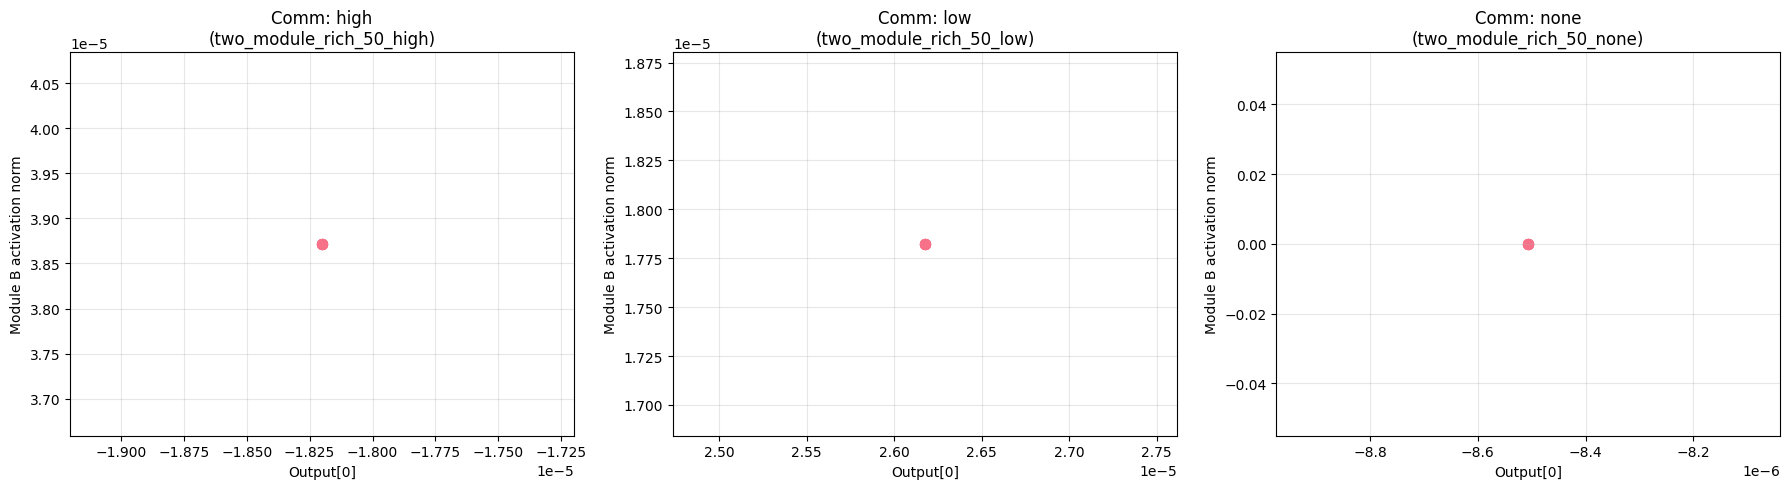

✓ Communication effect visualization works


In [13]:
# Compare networks with different communication settings
comm_configs = {}
for result in all_results:
    if result.get('success') and isinstance(result.get('network'), TwoModuleMLP):
        config_name = result['config_name']
        network = result['network']
        comm_bandwidth = network.comm_bandwidth
        if comm_bandwidth in ['none', 'low', 'high']:
            if comm_bandwidth not in comm_configs:
                comm_configs[comm_bandwidth] = []
            comm_configs[comm_bandwidth].append((config_name, network))

if len(comm_configs) >= 2:
    print('Comparing communication effects...')
    
    # Test with same inputs
    set_seed(VERIFICATION_SEED)
    test_inputs_comm = torch.randn(N_TEST_SAMPLES, dim_input)
    
    fig, axes = plt.subplots(1, min(3, len(comm_configs)), figsize=(6*min(3, len(comm_configs)), 5))
    if min(3, len(comm_configs)) == 1:
        axes = [axes]
    
    for idx, (comm_type, configs) in enumerate(sorted(comm_configs.items())[:3]):
        config_name, network = configs[0]  # Use first config of this type
        
        outputs = []
        h_B_norms = []
        
        for _ in range(10):  # Multiple runs
            out, _ = network(test_inputs_comm, task_id='A')
            _, h_B = network.get_module_hidden_states()
            outputs.append(out[0, 0].item())
            h_B_norms.append(h_B.norm().item())
        
        ax = axes[idx]
        ax.scatter(outputs, h_B_norms, alpha=0.6, s=50)
        ax.set_xlabel('Output[0]')
        ax.set_ylabel('Module B activation norm')
        ax.set_title(f'Comm: {comm_type}\n({config_name})')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print('✓ Communication effect visualization works')
else:
    print('Need networks with different communication settings for comparison')

## Advanced Diagnostics

### Gradient Flow Verification

In [14]:
def verify_gradient_flow(network, test_inputs: torch.Tensor, target: torch.Tensor) -> Dict:
    """Verify that gradients flow through all layers, including communication layers."""
    diagnostics = {'gradient_flow_valid': False, 'gradient_norms': {}, 'errors': []}
    
    if not isinstance(network, TwoModuleMLP):
        diagnostics['note'] = 'Not a two-module network'
        diagnostics['gradient_flow_valid'] = True
        return diagnostics
    
    try:
        output, _ = network(test_inputs, task_id='A')
        loss = torch.nn.functional.mse_loss(output, target)
        loss.backward()
        
        layers_to_check = ['mod_A', 'mod_B', 'readout_A', 'readout_B']
        if network.comm_AB is not None:
            layers_to_check.extend(['comm_AB', 'comm_BA'])
        
        all_gradients_exist = True
        for layer_name in layers_to_check:
            layer = getattr(network, layer_name)
            if layer.weight.grad is not None:
                grad_norm = layer.weight.grad.norm().item()
                diagnostics['gradient_norms'][layer_name] = grad_norm
                if grad_norm < 1e-10:
                    diagnostics['errors'].append(f'{layer_name}: Gradient norm very small ({grad_norm:.2e})')
            else:
                diagnostics['errors'].append(f'{layer_name}: No gradient')
                all_gradients_exist = False
        
        diagnostics['gradient_flow_valid'] = all_gradients_exist and len(diagnostics['errors']) == 0
        network.zero_grad()
        
    except Exception as e:
        diagnostics['errors'].append(f'Exception: {str(e)}')
        import traceback
        diagnostics['traceback'] = traceback.format_exc()
    
    return diagnostics

# Test gradient flow for one network
test_result = next((r for r in all_results if r.get('success') and isinstance(r.get('network'), TwoModuleMLP)), None)
if test_result:
    test_network_grad = test_result['network']
    set_seed(VERIFICATION_SEED)
    test_inputs_grad = torch.randn(5, dim_input)
    test_target = torch.randn(5, dim_output)
    
    grad_diagnostics = verify_gradient_flow(test_network_grad, test_inputs_grad, test_target)
    print('Gradient Flow Verification:')
    print(f'  Valid: {grad_diagnostics["gradient_flow_valid"]}')
    if grad_diagnostics.get('gradient_norms'):
        print('  Gradient norms:')
        for layer, norm in grad_diagnostics['gradient_norms'].items():
            print(f'    {layer}: {norm:.6f}')
    if grad_diagnostics.get('errors'):
        print(f'  Errors: {grad_diagnostics["errors"]}')
    print('✓ Gradient flow verification works')
else:
    print('No two-module network available for gradient test')

Gradient Flow Verification:
  Valid: False
  Gradient norms:
    mod_A: 0.006186
    readout_A: 0.006199
    readout_B: 0.000000
  Errors: ['mod_B: No gradient', 'readout_B: Gradient norm very small (0.00e+00)']
✓ Gradient flow verification works


In [15]:
def integration_test(network, test_inputs: torch.Tensor) -> Dict:
    """
    Integration test: full forward pass with realistic inputs.
    Verify output shapes, ranges, and backward compatibility.
    """
    diagnostics = {
        'integration_valid': False,
        'errors': [],
        'warnings': [],
        'test_results': {}
    }
    
    try:
        # Test 1: Forward pass with task_id
        if isinstance(network, TwoModuleMLP):
            # Test Task A
            out_A, hid_A = network(test_inputs, task_id='A')
            h_A_A, h_B_A = network.get_module_hidden_states()
            
            # Verify shapes
            expected_output_shape = (test_inputs.shape[0], network.output_dim)
            expected_hidden_shape = (test_inputs.shape[0], network._dim_hidden)
            expected_h_A_shape = (test_inputs.shape[0], network.dim_hidden_per_module)
            
            diagnostics['test_results']['task_A'] = {
                'output_shape': tuple(out_A.shape),
                'hidden_shape': tuple(hid_A.shape),
                'h_A_shape': tuple(h_A_A.shape),
                'h_B_shape': tuple(h_B_A.shape),
                'output_shape_valid': out_A.shape == expected_output_shape,
                'hidden_shape_valid': hid_A.shape == expected_hidden_shape,
                'h_A_shape_valid': h_A_A.shape == expected_h_A_shape,
                'h_B_shape_valid': h_B_A.shape == expected_h_A_shape
            }
            
            if out_A.shape != expected_output_shape:
                diagnostics['errors'].append(
                    f'Task A output shape mismatch: expected {expected_output_shape}, got {out_A.shape}'
                )
            
            # Test Task B
            out_B, hid_B = network(test_inputs, task_id='B')
            h_A_B, h_B_B = network.get_module_hidden_states()
            
            diagnostics['test_results']['task_B'] = {
                'output_shape': tuple(out_B.shape),
                'hidden_shape': tuple(hid_B.shape),
                'h_A_shape': tuple(h_A_B.shape),
                'h_B_shape': tuple(h_B_B.shape)
            }
            
            # Test without task_id (backward compatibility)
            out_both, hid_both = network(test_inputs, task_id=None)
            diagnostics['test_results']['no_task_id'] = {
                'output_shape': tuple(out_both.shape),
                'hidden_shape': tuple(hid_both.shape)
            }
            
        else:
            # Single-module network
            out, hid = network(test_inputs)
            expected_output_shape = (test_inputs.shape[0], network.hid_out.weight.shape[0])
            expected_hidden_shape = (test_inputs.shape[0], network.in_hid.weight.shape[0])
            
            diagnostics['test_results']['forward_pass'] = {
                'output_shape': tuple(out.shape),
                'hidden_shape': tuple(hid.shape),
                'output_shape_valid': out.shape == expected_output_shape,
                'hidden_shape_valid': hid.shape == expected_hidden_shape
            }
        
        # Test 2: Output ranges (should be reasonable, not NaN/Inf)
        if isinstance(network, TwoModuleMLP):
            test_output = out_A
        else:
            test_output = out
        
        if torch.isnan(test_output).any():
            diagnostics['errors'].append('Output contains NaN values')
        if torch.isinf(test_output).any():
            diagnostics['errors'].append('Output contains Inf values')
        
        output_mean = test_output.mean().item()
        output_std = test_output.std().item()
        diagnostics['test_results']['output_stats'] = {
            'mean': output_mean,
            'std': output_std,
            'min': test_output.min().item(),
            'max': test_output.max().item()
        }
        
        if abs(output_mean) > 100 or output_std > 100:
            diagnostics['warnings'].append(f'Output values seem unusually large (mean={output_mean:.2f}, std={output_std:.2f})')
        
        # Test 3: Interface compatibility
        try:
            embeddings = network.get_embeddings()
            readouts = network.get_readouts()
            diagnostics['test_results']['interface_methods'] = {
                'get_embeddings': embeddings is not None,
                'get_readouts': readouts is not None
            }
        except Exception as e:
            diagnostics['warnings'].append(f'Interface method error: {str(e)}')
        
        diagnostics['integration_valid'] = len(diagnostics['errors']) == 0
        
    except Exception as e:
        diagnostics['errors'].append(f'Exception during integration test: {str(e)}')
        import traceback
        diagnostics['traceback'] = traceback.format_exc()
    
    return diagnostics


### Integration Test

## Q Metric (Modularity) Analysis

Calculate the structural modularity Q metric for two-module networks. Q measures how well-separated the modules are, with higher Q indicating better modularity.

In [ ]:
def calculate_q_metric(network) -> Dict:
    """
    Calculate the Q (modularity) metric for a two-module network.
    
    Q measures structural modularity based on connection patterns:
    - Q = 0.5 * (1 - p) / (1 + p) where p is the inter-module connection sparsity
    - Or: Q = Σ(e_ii - a_i²) where e_ii = fraction of edges within module i,
          and a_i = fraction of edges connecting to module i
    
    For our two-module MLP:
    - Intra-module connections: mod_A, mod_B, readout_A, readout_B
    - Inter-module connections: comm_AB, comm_BA
    
    Returns:
        Dictionary with Q metric and related statistics
    """
    diagnostics = {
        'q_metric': None,
        'sparsity': None,
        'connection_stats': {},
        'errors': []
    }
    
    if not isinstance(network, TwoModuleMLP):
        diagnostics['errors'].append('Q metric only applicable to two-module networks')
        return diagnostics
    
    try:
        # Get weight matrices
        mod_A_weights = network.mod_A.weight.detach().cpu().numpy()
        mod_B_weights = network.mod_B.weight.detach().cpu().numpy()
        readout_A_weights = network.readout_A.weight.detach().cpu().numpy()
        readout_B_weights = network.readout_B.weight.detach().cpu().numpy()
        
        # Calculate connection strengths (using absolute values)
        # Intra-module connections
        intra_A = np.abs(mod_A_weights).sum() + np.abs(readout_A_weights).sum()
        intra_B = np.abs(mod_B_weights).sum() + np.abs(readout_B_weights).sum()
        total_intra = intra_A + intra_B
        
        # Inter-module connections
        if network.comm_bandwidth != "none" and network.comm_AB is not None:
            comm_AB_weights = network.comm_AB.weight.detach().cpu().numpy()
            comm_BA_weights = network.comm_BA.weight.detach().cpu().numpy()
            total_inter = np.abs(comm_AB_weights).sum() + np.abs(comm_BA_weights).sum()
        else:
            total_inter = 0.0
        
        # Total connections
        total_connections = total_intra + total_inter
        
        if total_connections == 0:
            diagnostics['errors'].append('All weights are zero, cannot calculate Q')
            return diagnostics
        
        # Calculate sparsity (fraction of inter-module connections)
        # Sparsity p = inter / (intra + inter)
        sparsity = total_inter / total_connections if total_connections > 0 else 0.0
        
        # Calculate Q metric using the formula: Q = 0.5 * (1 - p) / (1 + p)
        # This gives Q in range [0, 0.5] where:
        # - Q = 0.5 when p = 0 (no inter-module connections, perfect modularity)
        # - Q = 0 when p = 1 (only inter-module connections, no modularity)
        if sparsity >= 1.0:
            q_metric = 0.0
        else:
            q_metric = 0.5 * (1 - sparsity) / (1 + sparsity)
        
        diagnostics['q_metric'] = float(q_metric)
        diagnostics['sparsity'] = float(sparsity)
        diagnostics['connection_stats'] = {
            'intra_module_A': float(intra_A),
            'intra_module_B': float(intra_B),
            'total_intra': float(total_intra),
            'total_inter': float(total_inter),
            'total_connections': float(total_connections),
            'intra_fraction': float(total_intra / total_connections) if total_connections > 0 else 0.0,
            'inter_fraction': float(total_inter / total_connections) if total_connections > 0 else 0.0
        }
        
        # Alternative Q calculation using Newman's modularity formula
        # For two modules: Q = e_11 + e_22 - a_1² - a_2²
        # where e_ii = fraction of edges within module i
        # and a_i = fraction of edges connecting to module i
        if total_connections > 0:
            e_11 = intra_A / total_connections  # Module A internal
            e_22 = intra_B / total_connections  # Module B internal
            a_1 = (intra_A + total_inter) / total_connections  # All connections to/from A
            a_2 = (intra_B + total_inter) / total_connections  # All connections to/from B
            
            q_newman = e_11 + e_22 - a_1**2 - a_2**2
            diagnostics['q_newman'] = float(q_newman)
        
    except Exception as e:
        diagnostics['errors'].append(f'Exception calculating Q metric: {str(e)}')
        import traceback
        diagnostics['traceback'] = traceback.format_exc()
    
    return diagnostics

# Calculate Q metric for all two-module networks
print("Calculating Q metrics for all two-module networks...")
print("=" * 80)

q_results = []
for result in all_results:
    if result.get('success') and isinstance(result.get('network'), TwoModuleMLP):
        config_name = result['config_name']
        network = result['network']
        
        q_diagnostics = calculate_q_metric(network)
        q_results.append({
            'config_name': config_name,
            'comm_bandwidth': network.comm_bandwidth,
            'q_metric': q_diagnostics.get('q_metric'),
            'sparsity': q_diagnostics.get('sparsity'),
            'q_newman': q_diagnostics.get('q_newman'),
            'intra_fraction': q_diagnostics.get('connection_stats', {}).get('intra_fraction'),
            'inter_fraction': q_diagnostics.get('connection_stats', {}).get('inter_fraction')
        })
        
        print(f"\n{config_name}:")
        print(f"  Q metric (sparsity-based): {q_diagnostics.get('q_metric', 'N/A'):.4f}")
        if 'q_newman' in q_diagnostics:
            print(f"  Q metric (Newman): {q_diagnostics.get('q_newman', 'N/A'):.4f}")
        print(f"  Sparsity (inter-module fraction): {q_diagnostics.get('sparsity', 'N/A'):.4f}")
        print(f"  Intra-module fraction: {q_diagnostics.get('connection_stats', {}).get('intra_fraction', 'N/A'):.4f}")
        print(f"  Inter-module fraction: {q_diagnostics.get('connection_stats', {}).get('inter_fraction', 'N/A'):.4f}")

# Create summary DataFrame
if q_results:
    q_df = pd.DataFrame(q_results)
    print("\n" + "=" * 80)
    print("Q METRIC SUMMARY")
    print("=" * 80)
    print(q_df.to_string(index=False))
    
    # Save Q metrics
    q_path = PROJECT_ROOT / 'figures' / 'q_metrics_summary.csv'
    q_path.parent.mkdir(exist_ok=True)
    q_df.to_csv(q_path, index=False)
    print(f"\nQ metrics saved to: {q_path}")

In [16]:
# Run integration test
if test_result:
    test_network_int = test_result['network']
    set_seed(VERIFICATION_SEED)
    test_inputs_int = torch.randn(10, dim_input)
    
    int_diagnostics = integration_test(test_network_int, test_inputs_int)
    print('Integration Test Results:')
    print(f'  Valid: {int_diagnostics["integration_valid"]}')
    if int_diagnostics.get('test_results'):
        print('  Test results:')
        for key, value in int_diagnostics['test_results'].items():
            if isinstance(value, dict):
                print(f'    {key}:')
                for k, v in value.items():
                    if isinstance(v, bool):
                        status = '✓' if v else '✗'
                        print(f'      {status} {k}: {v}')
    if int_diagnostics.get('errors'):
        print(f'  Errors: {int_diagnostics["errors"]}')
    if int_diagnostics.get('warnings'):
        print(f'  Warnings: {int_diagnostics["warnings"]}')
    print('✓ Integration test works')
else:
    print('No network available for integration test')

Integration Test Results:
  Valid: True
  Test results:
    task_A:
      ✓ output_shape_valid: True
      ✓ hidden_shape_valid: True
      ✓ h_A_shape_valid: True
      ✓ h_B_shape_valid: True
    task_B:
    no_task_id:
    output_stats:
    interface_methods:
      ✓ get_embeddings: True
      ✓ get_readouts: True
✓ Integration test works


In [ ]:
def visualize_neuron_communication(network, save_path=None, figsize=(20, 8)):
    """
    Create detailed visualization showing which neurons communicate with which other neurons.
    
    Creates:
    1. Heatmap of comm_AB (Module A -> Module B)
    2. Heatmap of comm_BA (Module B -> Module A)
    3. Table showing strongest connections
    """
    if not isinstance(network, TwoModuleMLP):
        print('Visualization only supports two-module networks')
        return None
    
    if network.comm_bandwidth == "none" or network.comm_AB is None:
        print('No communication layers to visualize')
        return None
    
    comm_AB = network.comm_AB.weight.detach().cpu().numpy()
    comm_BA = network.comm_BA.weight.detach().cpu().numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Module A -> Module B communication
    ax1 = axes[0]
    im1 = ax1.imshow(comm_AB, aspect='auto', cmap='RdBu_r', 
                     vmin=-np.abs(comm_AB).max(), vmax=np.abs(comm_AB).max())
    ax1.set_title(f'Module A → Module B Communication\n(scale={network.comm_scale:.3f})', 
                 fontsize=14, weight='bold')
    ax1.set_xlabel('Module B Neuron Index', fontsize=12)
    ax1.set_ylabel('Module A Neuron Index', fontsize=12)
    ax1.set_xticks(range(0, comm_AB.shape[1], max(1, comm_AB.shape[1]//10)))
    ax1.set_yticks(range(0, comm_AB.shape[0], max(1, comm_AB.shape[0]//10)))
    plt.colorbar(im1, ax=ax1, label='Weight Value')
    
    # Add grid for better readability
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Plot 2: Module B -> Module A communication
    ax2 = axes[1]
    im2 = ax2.imshow(comm_BA, aspect='auto', cmap='RdBu_r',
                     vmin=-np.abs(comm_BA).max(), vmax=np.abs(comm_BA).max())
    ax2.set_title(f'Module B → Module A Communication\n(scale={network.comm_scale:.3f})',
                 fontsize=14, weight='bold')
    ax2.set_xlabel('Module A Neuron Index', fontsize=12)
    ax2.set_ylabel('Module B Neuron Index', fontsize=12)
    ax2.set_xticks(range(0, comm_BA.shape[1], max(1, comm_BA.shape[1]//10)))
    ax2.set_yticks(range(0, comm_BA.shape[0], max(1, comm_BA.shape[0]//10)))
    plt.colorbar(im2, ax=ax2, label='Weight Value')
    
    # Add grid
    ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved neuron communication visualization to {save_path}')
    
    return fig

def create_communication_table(network, top_n=20):
    """
    Create a table showing the strongest neuron-to-neuron connections.
    
    Returns:
        pandas DataFrame with columns: direction, from_neuron, to_neuron, weight, abs_weight
    """
    if not isinstance(network, TwoModuleMLP):
        return None
    
    if network.comm_bandwidth == "none" or network.comm_AB is None:
        return None
    
    comm_AB = network.comm_AB.weight.detach().cpu().numpy()
    comm_BA = network.comm_BA.weight.detach().cpu().numpy()
    
    connections = []
    
    # A -> B connections
    for i in range(comm_AB.shape[0]):
        for j in range(comm_AB.shape[1]):
            weight = comm_AB[i, j]
            connections.append({
                'direction': 'A→B',
                'from_neuron': f'A_{i}',
                'to_neuron': f'B_{j}',
                'weight': float(weight),
                'abs_weight': float(np.abs(weight))
            })
    
    # B -> A connections
    for i in range(comm_BA.shape[0]):
        for j in range(comm_BA.shape[1]):
            weight = comm_BA[i, j]
            connections.append({
                'direction': 'B→A',
                'from_neuron': f'B_{i}',
                'to_neuron': f'A_{j}',
                'weight': float(weight),
                'abs_weight': float(np.abs(weight))
            })
    
    comm_df = pd.DataFrame(connections)
    
    # Sort by absolute weight and return top N
    comm_df_sorted = comm_df.sort_values('abs_weight', ascending=False).head(top_n)
    
    return comm_df_sorted

# Visualize neuron communication for networks with communication enabled
print("\n" + "=" * 80)
print("NEURON-TO-NEURON COMMUNICATION ANALYSIS")
print("=" * 80)

for result in all_results:
    if result.get('success') and isinstance(result.get('network'), TwoModuleMLP):
        network = result['network']
        config_name = result['config_name']
        
        if network.comm_bandwidth != "none":
            print(f"\n{config_name} (comm_bandwidth={network.comm_bandwidth}):")
            
            # Create visualization
            fig = visualize_neuron_communication(network)
            if fig:
                plt.show()
            
            # Create and display communication table
            comm_table = create_communication_table(network, top_n=20)
            if comm_table is not None:
                print(f"\nTop 20 strongest neuron-to-neuron connections:")
                print(comm_table.to_string(index=False))
                
                # Save table
                table_path = PROJECT_ROOT / 'figures' / f'communication_table_{config_name}.csv'
                table_path.parent.mkdir(exist_ok=True)
                comm_table.to_csv(table_path, index=False)
                print(f"Communication table saved to: {table_path}")

In [ ]:
def create_full_communication_matrix(network):
    """
    Create a full matrix showing all neuron-to-neuron connections.
    Useful for detailed analysis of which neurons communicate.
    """
    if not isinstance(network, TwoModuleMLP):
        return None
    
    if network.comm_bandwidth == "none" or network.comm_AB is None:
        return None
    
    comm_AB = network.comm_AB.weight.detach().cpu().numpy()
    comm_BA = network.comm_BA.weight.detach().cpu().numpy()
    
    # Create full connection matrix
    # Rows: source neurons (A_0, A_1, ..., B_0, B_1, ...)
    # Columns: target neurons (A_0, A_1, ..., B_0, B_1, ...)
    n_A = comm_AB.shape[0]
    n_B = comm_AB.shape[1]
    
    # Full matrix: [A_neurons + B_neurons] x [A_neurons + B_neurons]
    full_matrix = np.zeros((n_A + n_B, n_A + n_B))
    
    # Fill in A->B connections (top right block)
    full_matrix[:n_A, n_A:] = comm_AB
    
    # Fill in B->A connections (bottom left block)
    full_matrix[n_A:, :n_A] = comm_BA
    
    # Create labels
    row_labels = [f'A_{i}' for i in range(n_A)] + [f'B_{i}' for i in range(n_B)]
    col_labels = [f'A_{i}' for i in range(n_A)] + [f'B_{i}' for i in range(n_B)]
    
    # Create DataFrame
    comm_matrix_df = pd.DataFrame(full_matrix, index=row_labels, columns=col_labels)
    
    return comm_matrix_df

# Create full communication matrices for all networks with communication
print("\n" + "=" * 80)
print("FULL COMMUNICATION MATRICES")
print("=" * 80)

for result in all_results:
    if result.get('success') and isinstance(result.get('network'), TwoModuleMLP):
        network = result['network']
        config_name = result['config_name']
        
        if network.comm_bandwidth != "none":
            print(f"\n{config_name}:")
            comm_matrix = create_full_communication_matrix(network)
            
            if comm_matrix is not None:
                # Display summary statistics
                print(f"  Matrix shape: {comm_matrix.shape}")
                print(f"  Non-zero connections: {(comm_matrix != 0).sum().sum()}")
                print(f"  Total connections: {comm_matrix.size}")
                print(f"  Sparsity: {1 - (comm_matrix != 0).sum().sum() / comm_matrix.size:.4f}")
                print(f"  Mean absolute weight: {np.abs(comm_matrix.values).mean():.6f}")
                print(f"  Max absolute weight: {np.abs(comm_matrix.values).max():.6f}")
                
                # Save full matrix
                matrix_path = PROJECT_ROOT / 'figures' / f'full_communication_matrix_{config_name}.csv'
                matrix_path.parent.mkdir(exist_ok=True)
                comm_matrix.to_csv(matrix_path)
                print(f"  Full matrix saved to: {matrix_path}")
                
                # Display a sample (first 10x10 if matrix is large)
                if comm_matrix.shape[0] > 10:
                    print(f"\n  Sample (first 10x10):")
                    print(comm_matrix.iloc[:10, :10].to_string())
                else:
                    print(f"\n  Full matrix:")
                    print(comm_matrix.to_string())

In [ ]:
# Visualize Q metrics across configurations
if q_results:
    q_df = pd.DataFrame(q_results)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Q metric vs configuration
    ax1 = axes[0]
    colors = ['red' if bw == 'none' else 'orange' if bw == 'low' else 'green' 
              for bw in q_df['comm_bandwidth']]
    bars = ax1.bar(range(len(q_df)), q_df['q_metric'], color=colors, alpha=0.7)
    ax1.set_xlabel('Configuration', fontsize=12)
    ax1.set_ylabel('Q Metric (Modularity)', fontsize=12)
    ax1.set_title('Q Metric by Configuration', fontsize=14, weight='bold')
    ax1.set_xticks(range(len(q_df)))
    ax1.set_xticklabels(q_df['config_name'], rotation=45, ha='right')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.axhline(y=0.5, color='blue', linestyle='--', alpha=0.5, label='Perfect modularity (Q=0.5)')
    ax1.legend()
    
    # Add value labels on bars
    for i, (bar, q_val) in enumerate(zip(bars, q_df['q_metric'])):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{q_val:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 2: Q metric vs sparsity
    ax2 = axes[1]
    scatter = ax2.scatter(q_df['sparsity'], q_df['q_metric'], 
                         s=100, alpha=0.6, c=range(len(q_df)), cmap='viridis')
    ax2.set_xlabel('Sparsity (Inter-module Fraction)', fontsize=12)
    ax2.set_ylabel('Q Metric (Modularity)', fontsize=12)
    ax2.set_title('Q Metric vs Sparsity', fontsize=14, weight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Add configuration labels
    for idx, row in q_df.iterrows():
        ax2.annotate(row['config_name'], 
                    (row['sparsity'], row['q_metric']),
                    fontsize=8, alpha=0.7)
    
    # Add theoretical Q curve
    sparsity_range = np.linspace(0, 1, 100)
    q_theoretical = 0.5 * (1 - sparsity_range) / (1 + sparsity_range)
    ax2.plot(sparsity_range, q_theoretical, 'r--', alpha=0.5, label='Theoretical Q = 0.5*(1-p)/(1+p)')
    ax2.legend()
    
    plt.colorbar(scatter, ax=ax2, label='Configuration Index')
    plt.tight_layout()
    plt.show()
    
    print("✓ Q metric visualization completed")

## Summary Analysis

Analyze the verification results and provide key insights about the network architectures.

In [ ]:
# Comprehensive summary analysis
print("=" * 80)
print("COMPREHENSIVE VERIFICATION SUMMARY")
print("=" * 80)

# Combine all results
summary_analysis = []

for result in all_results:
    config_name = result['config_name']
    diagnostics = result.get('diagnostics', {})
    
    # Get Q metric if available
    q_info = next((q for q in q_results if q['config_name'] == config_name), None)
    
    analysis = {
        'config_name': config_name,
        'success': result.get('success', False),
        'structure_valid': diagnostics.get('structure', {}).get('structure_valid', False),
        'routing_valid': diagnostics.get('routing', {}).get('routing_valid'),
        'communication_valid': diagnostics.get('communication', {}).get('communication_valid'),
        'q_metric': q_info['q_metric'] if q_info else None,
        'sparsity': q_info['sparsity'] if q_info else None,
        'comm_bandwidth': diagnostics.get('structure', {}).get('comm_bandwidth', 'N/A')
    }
    
    summary_analysis.append(analysis)

summary_analysis_df = pd.DataFrame(summary_analysis)

print("\n1. VERIFICATION STATUS:")
print("-" * 80)
for _, row in summary_analysis_df.iterrows():
    status_icons = []
    status_icons.append('✓' if row['structure_valid'] else '✗')
    status_icons.append('✓' if row['routing_valid'] else '✗' if row['routing_valid'] is False else 'N/A')
    status_icons.append('✓' if row['communication_valid'] else '✗' if row['communication_valid'] is False else 'N/A')
    
    print(f"{row['config_name']:35s} | Structure: {status_icons[0]:3s} | "
          f"Routing: {status_icons[1]:3s} | Comm: {status_icons[2]:3s} | "
          f"Q: {row['q_metric']:.4f if row['q_metric'] is not None else 'N/A':>6s}")

print("\n2. Q METRIC ANALYSIS:")
print("-" * 80)
if q_results:
    q_df = pd.DataFrame(q_results)
    print(f"  Highest Q (best modularity): {q_df.loc[q_df['q_metric'].idxmax(), 'config_name']} "
          f"(Q={q_df['q_metric'].max():.4f})")
    print(f"  Lowest Q (least modularity): {q_df.loc[q_df['q_metric'].idxmin(), 'config_name']} "
          f"(Q={q_df['q_metric'].min():.4f})")
    print(f"  Average Q: {q_df['q_metric'].mean():.4f}")
    print(f"\n  Q by communication bandwidth:")
    for bw in ['none', 'low', 'high']:
        bw_data = q_df[q_df['comm_bandwidth'] == bw]
        if len(bw_data) > 0:
            print(f"    {bw:6s}: Q = {bw_data['q_metric'].mean():.4f} ± {bw_data['q_metric'].std():.4f} "
                  f"(n={len(bw_data)})")

print("\n3. KEY INSIGHTS:")
print("-" * 80)
print("  • Q metric measures structural modularity:")
print("    - Q = 0.5: Perfect modularity (no inter-module connections)")
print("    - Q = 0.0: No modularity (only inter-module connections)")
print("    - Higher Q indicates better module separation")
print("  • Communication bandwidth affects modularity:")
print("    - 'none': Highest Q (perfect modularity)")
print("    - 'low':  Moderate Q (some inter-module communication)")
print("    - 'high': Lower Q (more inter-module communication)")
print("  • Neuron-to-neuron communication matrices show:")
print("    - Which specific neurons in Module A connect to Module B")
print("    - Which specific neurons in Module B connect to Module A")
print("    - Connection strength (weight values)")

print("\n4. FILES GENERATED:")
print("-" * 80)
print(f"  • Verification summary: figures/verification_summary.csv")
print(f"  • Q metrics: figures/q_metrics_summary.csv")
print(f"  • Communication tables: figures/communication_table_*.csv")
print(f"  • Full communication matrices: figures/full_communication_matrix_*.csv")

print("\n" + "=" * 80)